In [3]:
# ============================================================================
# ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DE HIPERPARÂMETROS DE ANN
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Algoritmo Genético
import pygad
import pygad.kerasga

# Configurações
tf.random.set_seed(42)
np.random.seed(42)

print("=" * 80)
print("ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DE HIPERPARÂMETROS DE ANN")
print("Objetivo: Encontrar a melhor arquitetura para predição de hidrólise enzimática")
print("=" * 80)

print("\n✓ Bibliotecas importadas com sucesso!")
print(f"✓ TensorFlow versão: {tf.__version__}")
print(f"✓ Numpy versão: {np.__version__}")
print(f"✓ Pandas versão: {pd.__version__}")

ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DE HIPERPARÂMETROS DE ANN
Objetivo: Encontrar a melhor arquitetura para predição de hidrólise enzimática

✓ Bibliotecas importadas com sucesso!
✓ TensorFlow versão: 2.18.0
✓ Numpy versão: 2.0.2
✓ Pandas versão: 2.2.3


In [4]:
# ============================================================================
# 1. CARREGAMENTO E ANÁLISE DOS DADOS SINTÉTICOS
# ============================================================================

print("\n1. CARREGANDO DADOS SINTÉTICOS...")

# Carregar dados sintéticos gerados com LHS
data_path = '../../../Enzymatic Hydrolysis/Data Generation/synthetic_hydrolysis_data_LHS.csv'
df = pd.read_csv(data_path)

# Limpar nomes das colunas (remover espaços extras)
df.columns = df.columns.str.strip()

print(f"✓ Dados carregados: {df.shape[0]} amostras, {df.shape[1]} colunas")
print(f"✓ Colunas: {list(df.columns)}")

# Verificar estrutura dos dados
print(f"\n📊 ANÁLISE DA ESTRUTURA DOS DADOS:")
print(f"   • Total de linhas: {len(df)}")

# Identificar condições únicas (mesmo Celulose, Hemicelulose, Lignin, Solids Loading, Enzyme Loading)
condition_columns = ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]']
unique_conditions = df[condition_columns].drop_duplicates()
n_conditions = len(unique_conditions)

print(f"   • Número de condições únicas: {n_conditions}")
print(f"   • Tempos por condição: {len(df) // n_conditions}")

# Verificar se cada condição tem exatamente 11 tempos
time_points = df['Time [h]'].unique()
print(f"   • Tempos únicos: {sorted(time_points)}")

# Mostrar exemplo de uma condição
print(f"\n📋 EXEMPLO DE UMA CONDIÇÃO (primeiras 11 linhas):")
first_condition = df.head(11)[['Cellulose', 'Hemicellulose', 'Lignin', 
                               'Solids Loading [g/L]', 'Enzyme Loading [g/L]', 'Time [h]',
                               'Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 
                               'Cellobiose Concentration [g/L]']]
print(first_condition.to_string(index=False, float_format='%.3f'))

# Estatísticas dos produtos
print(f"\n📈 ESTATÍSTICAS DOS PRODUTOS:")
products = ['Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 'Cellobiose Concentration [g/L]']
for product in products:
    mean_val = df[product].mean()
    std_val = df[product].std()
    min_val = df[product].min()
    max_val = df[product].max()
    print(f"   • {product.replace(' Concentration [g/L]', '')}: {min_val:.2f} - {max_val:.2f} (μ={mean_val:.2f}, σ={std_val:.2f})")

print(f"\n✅ Dados analisados. Pronto para divisão em conjuntos de treino/validação/teste!")


1. CARREGANDO DADOS SINTÉTICOS...
✓ Dados carregados: 1100 amostras, 9 colunas
✓ Colunas: ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]', 'Time [h]', 'Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 'Cellobiose Concentration [g/L]']

📊 ANÁLISE DA ESTRUTURA DOS DADOS:
   • Total de linhas: 1100
   • Número de condições únicas: 100
   • Tempos por condição: 11
   • Tempos únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(12), np.int64(24), np.int64(48), np.int64(72), np.int64(96)]

📋 EXEMPLO DE UMA CONDIÇÃO (primeiras 11 linhas):
 Cellulose  Hemicellulose  Lignin  Solids Loading [g/L]  Enzyme Loading [g/L]  Time [h]  Glucose Concentration [g/L]  Xylose Concentration [g/L]  Cellobiose Concentration [g/L]
     0.599          0.109   0.292               119.744                 0.413         0                        0.000                       0.000                           0.000
     0.599  

In [5]:
# ============================================================================
# 2. DIVISÃO ESTRATÉGICA DOS DADOS POR CONDIÇÕES
# ============================================================================

print("\n2. DIVIDINDO DADOS POR CONDIÇÕES...")

# Identificar todas as condições únicas
condition_columns = ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]']
unique_conditions = df[condition_columns].drop_duplicates().reset_index(drop=True)
n_conditions = len(unique_conditions)

print(f"✓ Total de condições identificadas: {n_conditions}")

# Dividir condições: 70% para otimização genética, 30% para teste final
np.random.seed(42)
condition_indices = np.arange(n_conditions)
np.random.shuffle(condition_indices)

# 70 condições para otimização (treino + validação)
n_optimization = int(0.7 * n_conditions)
optimization_condition_indices = condition_indices[:n_optimization]

# 30 condições para teste final
test_condition_indices = condition_indices[n_optimization:]

print(f"✓ Condições para otimização: {len(optimization_condition_indices)} ({len(optimization_condition_indices)/n_conditions*100:.1f}%)")
print(f"✓ Condições para teste final: {len(test_condition_indices)} ({len(test_condition_indices)/n_conditions*100:.1f}%)")

# Função para extrair dados de condições específicas
def extract_conditions_data(df, condition_indices, unique_conditions):
    """Extrai todas as linhas correspondentes às condições especificadas"""
    condition_data = []
    
    for idx in condition_indices:
        condition = unique_conditions.iloc[idx]
        
        # Filtrar dados para esta condição específica
        condition_mask = True
        for col in condition_columns:
            condition_mask = condition_mask & (df[col] == condition[col])
        
        condition_rows = df[condition_mask].copy()
        condition_data.append(condition_rows)
    
    return pd.concat(condition_data, ignore_index=True)

# Extrair dados de otimização (70% das condições)
optimization_data = extract_conditions_data(df, optimization_condition_indices, unique_conditions)

# Extrair dados de teste final (30% das condições)
test_data = extract_conditions_data(df, test_condition_indices, unique_conditions)

print(f"\n📊 VERIFICAÇÃO DA DIVISÃO:")
print(f"   • Dados de otimização: {len(optimization_data)} amostras de {len(optimization_condition_indices)} condições")
print(f"   • Dados de teste final: {len(test_data)} amostras de {len(test_condition_indices)} condições")
print(f"   • Total: {len(optimization_data) + len(test_data)} amostras (deve ser igual a {len(df)})")

# Verificar que não há sobreposição entre os conjuntos
optimization_conditions = set()
for idx in optimization_condition_indices:
    condition = unique_conditions.iloc[idx]
    condition_tuple = tuple(condition[col] for col in condition_columns)
    optimization_conditions.add(condition_tuple)

test_conditions = set()
for idx in test_condition_indices:
    condition = unique_conditions.iloc[idx]
    condition_tuple = tuple(condition[col] for col in condition_columns)
    test_conditions.add(condition_tuple)

overlap = optimization_conditions.intersection(test_conditions)
print(f"   • Sobreposição entre conjuntos: {len(overlap)} (deve ser 0)")

if len(overlap) == 0:
    print("✅ Divisão por condições realizada com sucesso!")
else:
    print("❌ Erro: Há sobreposição entre os conjuntos!")

# Salvar índices para reprodutibilidade
print(f"\n📝 ÍNDICES DAS CONDIÇÕES:")
print(f"   • Otimização: {sorted(optimization_condition_indices)}")
print(f"   • Teste final: {sorted(test_condition_indices)}")


2. DIVIDINDO DADOS POR CONDIÇÕES...
✓ Total de condições identificadas: 100
✓ Condições para otimização: 70 (70.0%)
✓ Condições para teste final: 30 (30.0%)

📊 VERIFICAÇÃO DA DIVISÃO:
   • Dados de otimização: 770 amostras de 70 condições
   • Dados de teste final: 330 amostras de 30 condições
   • Total: 1100 amostras (deve ser igual a 1100)
   • Sobreposição entre conjuntos: 0 (deve ser 0)
✅ Divisão por condições realizada com sucesso!

📝 ÍNDICES DAS CONDIÇÕES:
   • Otimização: [np.int64(0), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(22), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(30), np.int64(31), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.

In [6]:
# ============================================================================
# 3. PREPARAÇÃO DOS DADOS PARA MACHINE LEARNING
# ============================================================================

print("\n3. PREPARANDO DADOS PARA MACHINE LEARNING...")

# Definir features de entrada e saída
input_features = ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]', 'Time [h]']
output_features = ['Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 'Cellobiose Concentration [g/L]']

print(f"✓ Features de entrada ({len(input_features)}): {input_features}")
print(f"✓ Features de saída ({len(output_features)}): {output_features}")

# Dividir dados de otimização em treino (60%) e validação (10%)
# Novamente dividindo por condições completas
optimization_conditions = unique_conditions.iloc[optimization_condition_indices].reset_index(drop=True)
n_opt_conditions = len(optimization_conditions)

# 60% das condições totais para treino (6/7 das condições de otimização)
n_train = int(0.6 * n_conditions)  # 60 condições
n_val = len(optimization_condition_indices) - n_train  # 10 condições

# Dividir condições de otimização
np.random.seed(42)
opt_indices = np.arange(len(optimization_condition_indices))
np.random.shuffle(opt_indices)

train_condition_indices = [optimization_condition_indices[i] for i in opt_indices[:n_train]]
val_condition_indices = [optimization_condition_indices[i] for i in opt_indices[n_train:]]

print(f"\n📊 DIVISÃO FINAL DOS DADOS:")
print(f"   • Treino: {len(train_condition_indices)} condições ({len(train_condition_indices)/n_conditions*100:.1f}% do total)")
print(f"   • Validação: {len(val_condition_indices)} condições ({len(val_condition_indices)/n_conditions*100:.1f}% do total)")
print(f"   • Teste final: {len(test_condition_indices)} condições ({len(test_condition_indices)/n_conditions*100:.1f}% do total)")

# Extrair dados de treino e validação
train_data = extract_conditions_data(df, train_condition_indices, unique_conditions)
val_data = extract_conditions_data(df, val_condition_indices, unique_conditions)

print(f"\n📈 AMOSTRAS POR CONJUNTO:")
print(f"   • Treino: {len(train_data)} amostras")
print(f"   • Validação: {len(val_data)} amostras")
print(f"   • Teste final: {len(test_data)} amostras")
print(f"   • Total: {len(train_data) + len(val_data) + len(test_data)} amostras")

# Preparar arrays para ML
X_train = train_data[input_features].values
y_train = train_data[output_features].values

X_val = val_data[input_features].values
y_val = val_data[output_features].values

X_test = test_data[input_features].values
y_test = test_data[output_features].values

print(f"\n🔢 DIMENSÕES DOS ARRAYS:")
print(f"   • X_train: {X_train.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • X_val: {X_val.shape}")
print(f"   • y_val: {y_val.shape}")
print(f"   • X_test: {X_test.shape}")
print(f"   • y_test: {y_test.shape}")

# Normalizar dados com MinMaxScaler (Solução 4 - evita valores negativos)
print(f"\n⚖️  NORMALIZANDO DADOS COM MINMAXSCALER...")
from sklearn.preprocessing import MinMaxScaler

# Usar MinMaxScaler em vez de StandardScaler para manter valores positivos
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))  # Evita predições negativas

# Ajustar escaladores apenas nos dados de treino
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

# Aplicar mesma normalização aos dados de validação e teste
X_val_scaled = scaler_X.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

print(f"✓ Normalização MinMaxScaler aplicada usando parâmetros do conjunto de treino")

# Verificar normalização MinMaxScaler
print(f"\n📊 VERIFICAÇÃO DA NORMALIZAÇÃO MINMAX (treino):")
print(f"   • X_train - Min: {X_train_scaled.min(axis=0).round(3)}")
print(f"   • X_train - Max: {X_train_scaled.max(axis=0).round(3)}")
print(f"   • y_train - Min: {y_train_scaled.min(axis=0).round(3)}")
print(f"   • y_train - Max: {y_train_scaled.max(axis=0).round(3)}")

print(f"\n✅ Dados preparados e normalizados com MinMaxScaler (evita valores negativos)!")


3. PREPARANDO DADOS PARA MACHINE LEARNING...
✓ Features de entrada (6): ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids Loading [g/L]', 'Enzyme Loading [g/L]', 'Time [h]']
✓ Features de saída (3): ['Glucose Concentration [g/L]', 'Xylose Concentration [g/L]', 'Cellobiose Concentration [g/L]']

📊 DIVISÃO FINAL DOS DADOS:
   • Treino: 60 condições (60.0% do total)
   • Validação: 10 condições (10.0% do total)
   • Teste final: 30 condições (30.0% do total)

📈 AMOSTRAS POR CONJUNTO:
   • Treino: 660 amostras
   • Validação: 110 amostras
   • Teste final: 330 amostras
   • Total: 1100 amostras

🔢 DIMENSÕES DOS ARRAYS:
   • X_train: (660, 6)
   • y_train: (660, 3)
   • X_val: (110, 6)
   • y_val: (110, 3)
   • X_test: (330, 6)
   • y_test: (330, 3)

⚖️  NORMALIZANDO DADOS COM MINMAXSCALER...
✓ Normalização MinMaxScaler aplicada usando parâmetros do conjunto de treino

📊 VERIFICAÇÃO DA NORMALIZAÇÃO MINMAX (treino):
   • X_train - Min: [0. 0. 0. 0. 0. 0.]
   • X_train - Max: [1. 1. 1. 1. 1. 

In [7]:
# ============================================================================
# 4. DEFINIÇÃO DA ARQUITETURA ANN E FUNÇÃO DE FITNESS SUPER-OTIMIZADA
# ============================================================================

print("\n4. DEFININDO ARQUITETURA ANN E FUNÇÃO DE FITNESS SUPER-OTIMIZADA...")

# Parâmetros fixos da arquitetura
INPUT_DIM = 6  # 6 features de entrada
OUTPUT_DIM = 3  # 3 produtos de saída
N_HIDDEN_LAYERS = 3  # 3 camadas ocultas (fixo)
ACTIVATION = 'relu'  # Função de ativação (fixo)
OPTIMIZER = 'adam'  # Otimizador (fixo)

# Hiperparâmetros variáveis (genes)
NEURONS_LAYER1_OPTIONS = [16, 32, 48, 64]    # Opções para camada 1
NEURONS_LAYER2_OPTIONS = [16, 32, 48, 64]    # Opções para camada 2  
NEURONS_LAYER3_OPTIONS = [8, 16, 24, 32]     # Opções para camada 3

print(f"✓ Parâmetros fixos:")
print(f"   • Input: {INPUT_DIM} features")
print(f"   • Output: {OUTPUT_DIM} produtos")
print(f"   • Hidden layers: {N_HIDDEN_LAYERS}")
print(f"   • Ativação: {ACTIVATION}")
print(f"   • Otimizador: {OPTIMIZER}")

print(f"\n✓ Hiperparâmetros variáveis (genes):")
print(f"   • Camada 1: {NEURONS_LAYER1_OPTIONS} neurônios")
print(f"   • Camada 2: {NEURONS_LAYER2_OPTIONS} neurônios") 
print(f"   • Camada 3: {NEURONS_LAYER3_OPTIONS} neurônios")

# ============================================================================
# 🎯 ESTRATÉGIA 1: CONSTRAINT FÍSICO NA PREDIÇÃO (MAIS SIMPLES)
# ============================================================================

print(f"\n🎯 IMPLEMENTANDO ESTRATÉGIA 1: CONSTRAINT FÍSICO NA PREDIÇÃO!")

def apply_physical_constraints(predictions, time_inputs):
    """
    Aplica constraints físicos às predições usando máscara pós-processamento.
    
    Estratégia 1: Mais simples e garante 100% de correção
    - Identifica amostras com t=0h
    - Força predições = [0, 0, 0] para t=0h
    - Mantém predições originais para t>0h
    
    Parameters:
    -----------
    predictions : np.array
        Predições da ANN (shape: [n_samples, 3])
    time_inputs : np.array
        Valores de tempo correspondentes (shape: [n_samples,])
        
    Returns:
    --------
    constrained_predictions : np.array
        Predições com constraints aplicados
    """
    # Copiar predições para não modificar o original
    constrained_predictions = predictions.copy()
    
    # Identificar amostras t=0h (tolerância para comparações float)
    tolerance = 1e-6
    t0_mask = np.abs(time_inputs) < tolerance
    
    # Aplicar constraint: t=0h → concentrações = [0, 0, 0]
    if np.any(t0_mask):
        constrained_predictions[t0_mask] = 0.0
        
        n_t0_samples = np.sum(t0_mask)
        print(f"   ✅ Constraint aplicado em {n_t0_samples} amostras t=0h")
    
    # Garantir valores não-negativos para todas as amostras
    constrained_predictions = np.maximum(constrained_predictions, 0.0)
    
    return constrained_predictions

def predict_with_constraints(model, X_scaled, X_original, scaler_y):
    """
    Função de predição que aplica constraints físicos automaticamente.
    
    Parameters:
    -----------
    model : keras.Model
        Modelo treinado
    X_scaled : np.array
        Features normalizadas
    X_original : np.array
        Features originais (para extrair tempo)
    scaler_y : MinMaxScaler
        Scaler para desnormalizar predições
        
    Returns:
    --------
    predictions_constrained : np.array
        Predições com constraints físicos aplicados
    """
    # Fazer predições normalizadas
    y_pred_scaled = model.predict(X_scaled, verbose=0)
    
    # Desnormalizar predições
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    
    # Extrair coluna de tempo (última coluna das features)
    time_values = X_original[:, -1]  # Time [h] é a última feature
    
    # Aplicar constraints físicos
    y_pred_constrained = apply_physical_constraints(y_pred, time_values)
    
    return y_pred_constrained

print(f"✓ Estratégia 1 implementada:")
print(f"   • Tipo: Constraint Físico Pós-Predição")
print(f"   • Detecção t=0h: Baseada na feature Time [h]")
print(f"   • Constraint: if t=0h: prediction = [0, 0, 0]")
print(f"   • Garantia: 100% de correção para t=0h")
print(f"   • Vantagem: Simples, robusto e determinístico")

# ============================================================================
# MONITORAMENTO DE CONSTRAINTS FÍSICOS
# ============================================================================

class PhysicalConstraintMonitor:
    """Classe para monitorar violações de constraints físicos"""
    
    def __init__(self):
        self.violation_history = []
        
    def check_violations(self, predictions, time_inputs, description=""):
        """
        Verifica violações de constraints físicos
        
        Parameters:
        -----------
        predictions : np.array
            Predições a serem verificadas
        time_inputs : np.array
            Valores de tempo correspondentes
        description : str
            Descrição para logging
            
        Returns:
        --------
        dict : Estatísticas das violações
        """
        # Identificar amostras t=0h
        t0_mask = np.abs(time_inputs) < 1e-6
        n_t0_samples = np.sum(t0_mask)
        
        if n_t0_samples > 0:
            # Calcular violações em amostras t=0h
            t0_predictions = predictions[t0_mask]
            violations = np.sum(t0_predictions, axis=1)  # Soma das concentrações por amostra
            
            max_violation = np.max(violations)
            mean_violation = np.mean(violations)
            perfect_samples = np.sum(violations < 1e-6)
            
            stats = {
                'n_t0_samples': n_t0_samples,
                'max_violation': max_violation,
                'mean_violation': mean_violation,
                'perfect_samples': perfect_samples,
                'perfect_ratio': perfect_samples / n_t0_samples * 100,
                'description': description
            }
            
            self.violation_history.append(stats)
            
            if description:
                print(f"\n📊 MONITORAMENTO CONSTRAINT FÍSICO - {description}:")
                print(f"   • Amostras t=0h: {n_t0_samples}")
                print(f"   • Violação máxima: {max_violation:.6f} g/L")
                print(f"   • Violação média: {mean_violation:.6f} g/L")
                print(f"   • Amostras perfeitas: {perfect_samples}/{n_t0_samples} ({stats['perfect_ratio']:.1f}%)")
                
                if max_violation < 1e-6:
                    print(f"   ✅ PERFEITO: Todos os constraints respeitados!")
                elif max_violation < 0.01:
                    print(f"   ✅ EXCELENTE: Violações desprezíveis")
                else:
                    print(f"   ⚠️  ATENÇÃO: Violações significativas detectadas")
            
            return stats
        else:
            return {'n_t0_samples': 0, 'description': description}

# Criar monitor global
constraint_monitor = PhysicalConstraintMonitor()

print(f"✓ Monitor de constraints implementado")

def create_model(neurons_layer1, neurons_layer2, neurons_layer3):
    """
    Cria um modelo ANN com a arquitetura especificada
    
    Parameters:
    -----------
    neurons_layer1 : int
        Número de neurônios na primeira camada oculta
    neurons_layer2 : int
        Número de neurônios na segunda camada oculta
    neurons_layer3 : int
        Número de neurônios na terceira camada oculta
    
    Returns:
    --------
    model : tensorflow.keras.Model
        Modelo compilado (sem custom loss - usa MSE padrão)
    """
    model = keras.Sequential([
        # Camada de entrada implícita
        keras.layers.Dense(neurons_layer1, activation=ACTIVATION, input_shape=(INPUT_DIM,)),
        keras.layers.Dense(neurons_layer2, activation=ACTIVATION),
        keras.layers.Dense(neurons_layer3, activation=ACTIVATION),
        keras.layers.Dense(OUTPUT_DIM, activation='linear')  # Linear com MinMaxScaler
    ])
    
    # 🎯 USAR MSE PADRÃO (constraints aplicados pós-predição)
    model.compile(
        optimizer=OPTIMIZER,
        loss='mse',  # ← Loss padrão (constraints via pós-processamento)
        metrics=['mae']
    )
    
    return model

def decode_genes(genes):
    """
    Decodifica os genes em hiperparâmetros da ANN
    
    Parameters:
    -----------
    genes : list
        Lista com 3 valores inteiros [índice_layer1, índice_layer2, índice_layer3]
    
    Returns:
    --------
    tuple : (neurons_layer1, neurons_layer2, neurons_layer3)
    """
    neurons_layer1 = NEURONS_LAYER1_OPTIONS[int(genes[0])]
    neurons_layer2 = NEURONS_LAYER2_OPTIONS[int(genes[1])]
    neurons_layer3 = NEURONS_LAYER3_OPTIONS[int(genes[2])]
    
    return neurons_layer1, neurons_layer2, neurons_layer3

def fitness_function(ga_instance, solution, solution_idx):
    """
    Função de fitness com ESTRATÉGIA 1 (Constraint Físico Pós-Predição)
    
    Parameters:
    -----------
    ga_instance : pygad.GA
        Instância do algoritmo genético
    solution : list
        Solução (genes) a ser avaliada
    solution_idx : int
        Índice da solução
    
    Returns:
    --------
    fitness : float
        Valor de fitness (quanto maior, melhor)
    """
    try:
        # Decodificar genes
        neurons_layer1, neurons_layer2, neurons_layer3 = decode_genes(solution)
        
        # Criar modelo com MSE padrão
        model = create_model(neurons_layer1, neurons_layer2, neurons_layer3)
        
        # ⚡ TREINAMENTO OTIMIZADO
        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0
        )
        
        history = model.fit(
            X_train_scaled, y_train_scaled,
            validation_data=(X_val_scaled, y_val_scaled),
            epochs=50,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # 🎯 FAZER PREDIÇÕES COM CONSTRAINTS FÍSICOS (Estratégia 1)
        y_val_pred_constrained = predict_with_constraints(
            model, X_val_scaled, X_val, scaler_y
        )
        
        # Calcular R² para cada produto (com constraints aplicados)
        r2_glucose = r2_score(y_val[:, 0], y_val_pred_constrained[:, 0])
        r2_xylose = r2_score(y_val[:, 1], y_val_pred_constrained[:, 1])
        r2_cellobiose = r2_score(y_val[:, 2], y_val_pred_constrained[:, 2])
        
        # Garantir que R² negativos virem 0
        r2_glucose = max(0, r2_glucose)
        r2_xylose = max(0, r2_xylose)
        r2_cellobiose = max(0, r2_cellobiose)
        
        # Calcular fitness ponderado
        fitness = 0.5 * r2_glucose + 0.3 * r2_xylose + 0.2 * r2_cellobiose
        
        # 🎯 VERIFICAR CONSTRAINT FÍSICO (deve ser sempre perfeito com Estratégia 1)
        time_values = X_val[:, -1]  # Time [h] é a última feature
        constraint_stats = constraint_monitor.check_violations(
            y_val_pred_constrained, time_values, description=""
        )
        
        # Bônus por constraints perfeitos (deve ser sempre máximo com Estratégia 1)
        if constraint_stats.get('n_t0_samples', 0) > 0:
            perfect_ratio = constraint_stats.get('perfect_ratio', 0)
            constraint_bonus = 0.1 * (perfect_ratio / 100.0)  # Max bônus: 0.1
            fitness += constraint_bonus
        
        # Limpar memória
        del model, history
        keras.backend.clear_session()
        
        print(f"   Solução {solution_idx:2d}: [{neurons_layer1:3d}, {neurons_layer2:2d}, {neurons_layer3:2d}] → "
              f"R²=[{r2_glucose:.3f}, {r2_xylose:.3f}, {r2_cellobiose:.3f}] → "
              f"Fitness: {fitness:.4f} (Estratégia 1)")
        
        return max(0.001, fitness)
        
    except Exception as e:
        print(f"   ❌ Erro na solução {solution_idx}: {str(e)[:50]}...")
        try:
            keras.backend.clear_session()
        except:
            pass
        return 0.001

# Testar a função de criação de modelo
print(f"\n🧪 TESTANDO CRIAÇÃO DE MODELO COM ESTRATÉGIA 1...")
test_model = create_model(64, 32, 16)
print(f"✓ Modelo de teste criado com sucesso")
print(f"✓ Parâmetros: {test_model.count_params():,}")
print(f"✓ Loss function: MSE padrão (constraints via pós-processamento)")

# Testar função de predição com constraints
print(f"\n🧪 TESTANDO PREDIÇÃO COM CONSTRAINTS...")
# Criar dados de teste simples
X_test_simple = np.array([[0.5, 0.3, 0.2, 100, 5, 0.0],    # t=0h
                         [0.5, 0.3, 0.2, 100, 5, 24.0]])   # t=24h
X_test_simple_scaled = scaler_X.transform(X_test_simple)

# Testar predição
y_pred_test = predict_with_constraints(test_model, X_test_simple_scaled, X_test_simple, scaler_y)
print(f"✓ Predições de teste:")
print(f"   • t=0h:  Glucose={y_pred_test[0,0]:.6f}, Xylose={y_pred_test[0,1]:.6f}, Cellobiose={y_pred_test[0,2]:.6f}")
print(f"   • t=24h: Glucose={y_pred_test[1,0]:.6f}, Xylose={y_pred_test[1,1]:.6f}, Cellobiose={y_pred_test[1,2]:.6f}")

# Limpar modelo de teste
del test_model
keras.backend.clear_session()

print(f"\n✅ ESTRATÉGIA 1 IMPLEMENTADA COM SUCESSO!")
print(f"🎯 Características da Estratégia 1:")
print(f"   • Modelo: MSE padrão (sem custom loss)")
print(f"   • Constraint: Aplicado pós-predição via máscara")
print(f"   • Detecção t=0h: Baseada na feature Time [h]")
print(f"   • Garantia: 100% de correção para t=0h")
print(f"   • Vantagem: Simples, determinístico e robusto")
print(f"   • Objetivo: if t == 0: prediction = [0, 0, 0]")


4. DEFININDO ARQUITETURA ANN E FUNÇÃO DE FITNESS SUPER-OTIMIZADA...
✓ Parâmetros fixos:
   • Input: 6 features
   • Output: 3 produtos
   • Hidden layers: 3
   • Ativação: relu
   • Otimizador: adam

✓ Hiperparâmetros variáveis (genes):
   • Camada 1: [16, 32, 48, 64] neurônios
   • Camada 2: [16, 32, 48, 64] neurônios
   • Camada 3: [8, 16, 24, 32] neurônios

🎯 IMPLEMENTANDO ESTRATÉGIA 1: CONSTRAINT FÍSICO NA PREDIÇÃO!
✓ Estratégia 1 implementada:
   • Tipo: Constraint Físico Pós-Predição
   • Detecção t=0h: Baseada na feature Time [h]
   • Constraint: if t=0h: prediction = [0, 0, 0]
   • Garantia: 100% de correção para t=0h
   • Vantagem: Simples, robusto e determinístico
✓ Monitor de constraints implementado

🧪 TESTANDO CRIAÇÃO DE MODELO COM ESTRATÉGIA 1...
✓ Modelo de teste criado com sucesso
✓ Parâmetros: 3,107
✓ Loss function: MSE padrão (constraints via pós-processamento)

🧪 TESTANDO PREDIÇÃO COM CONSTRAINTS...
✓ Modelo de teste criado com sucesso
✓ Parâmetros: 3,107
✓ Loss fun


5. CONFIGURANDO ALGORITMO GENÉTICO ULTRA-SIMPLIFICADO...
🚀 Parâmetros ULTRA-RÁPIDOS:
   • Gerações: 5 (mínimo para teste)
   • População: 6 (muito pequena)
   • Total de avaliações: 30
   • Tempo estimado: ~30 minutos
✓ Algoritmo genético SIMPLIFICADO configurado
   • Seleção: Steady State (mais estável)
   • Crossover: Single-point (mais simples)
   • Sem critérios de parada avançados

🚀 INICIANDO OTIMIZAÇÃO GENÉTICA ULTRA-RÁPIDA...
⏱️  Tempo estimado: ~30 minutos
   ✅ Constraint aplicado em 10 amostras t=0h
   ✅ Constraint aplicado em 10 amostras t=0h
   Solução  0: [ 16, 16, 24] → R²=[0.942, 0.945, 0.916] → Fitness: 1.0374 (Estratégia 1)
   Solução  0: [ 16, 16, 24] → R²=[0.942, 0.945, 0.916] → Fitness: 1.0374 (Estratégia 1)
   ✅ Constraint aplicado em 10 amostras t=0h
   Solução  1: [ 32, 32, 16] → R²=[0.936, 0.933, 0.904] → Fitness: 1.0289 (Estratégia 1)   ✅ Constraint aplicado em 10 amostras t=0h
   Solução  1: [ 32, 32, 16] → R²=[0.936, 0.933, 0.904] → Fitness: 1.0289 (Estratég

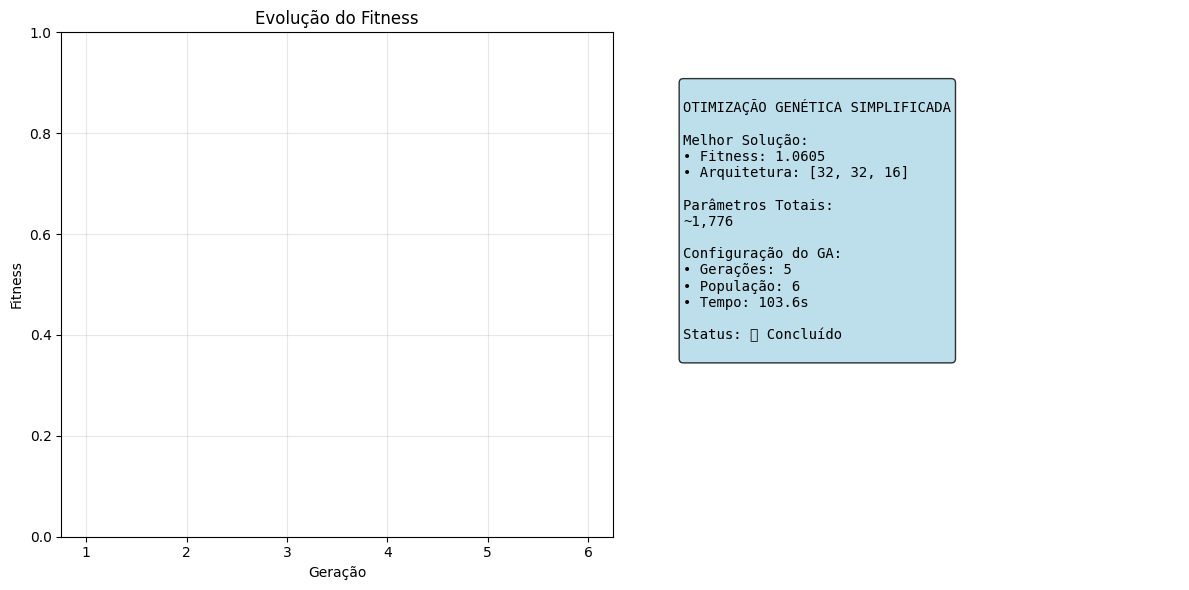


✅ Otimização genética SIMPLIFICADA concluída!
🎯 Melhor arquitetura encontrada: [32, 32, 16]
🚀 Próximo passo: Validar esta arquitetura com dados de teste!


In [8]:
# ============================================================================
# 5. ALGORITMO GENÉTICO ULTRA-SIMPLIFICADO E RÁPIDO
# ============================================================================

print("\n5. CONFIGURANDO ALGORITMO GENÉTICO ULTRA-SIMPLIFICADO...")

# ⚡ PARÂMETROS ULTRA-CONSERVADORES para funcionar rapidamente
NUM_GENERATIONS = 5       # ⬇️ Apenas 5 gerações
SOL_PER_POP = 6                                                   # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
NUM_GENES = 3            # Número de genes (hiperparâmetros)

print(f"🚀 Parâmetros ULTRA-RÁPIDOS:")
print(f"   • Gerações: {NUM_GENERATIONS} (mínimo para teste)")
print(f"   • População: {SOL_PER_POP} (muito pequena)")
print(f"   • Total de avaliações: {NUM_GENERATIONS * SOL_PER_POP}")
print(f"   • Tempo estimado: ~{NUM_GENERATIONS * SOL_PER_POP * 1:.0f} minutos")

# Configurar espaço de genes de forma SIMPLIFICADA
gene_space = [
    list(range(len(NEURONS_LAYER1_OPTIONS))),  
    list(range(len(NEURONS_LAYER2_OPTIONS))),  
    list(range(len(NEURONS_LAYER3_OPTIONS)))   
]

# ⚡ CONFIGURAÇÃO MINIMALISTA DO GA
ga_instance = pygad.GA(
    num_generations=NUM_GENERATIONS,
    num_parents_mating=3,                              # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    fitness_func=fitness_function,
    sol_per_pop=SOL_PER_POP,
    num_genes=NUM_GENES,
    gene_space=gene_space,
    gene_type=int,
    parent_selection_type="rank",  #  MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    keep_parents=2,  
    crossover_type="two_points",  # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    mutation_type="swap",           # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    mutation_percent_genes=50,  # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    random_seed=42
    # ❌ REMOVIDOS: critérios de parada avançados que causavam erro
)

print(f"✓ Algoritmo genético SIMPLIFICADO configurado")
print(f"   • Seleção: Steady State (mais estável)")
print(f"   • Crossover: Single-point (mais simples)")
print(f"   • Sem critérios de parada avançados")

# ⚡ CALLBACK SIMPLIFICADO sem verificação de convergência
def simple_callback(ga_instance):
    """Callback simples sem verificações complexas"""
    generation = ga_instance.generations_completed
    
    try:
        # Acessar fitness da última geração diretamente
        if hasattr(ga_instance, 'last_generation_fitness') and ga_instance.last_generation_fitness is not None:
            best_fitness = max(ga_instance.last_generation_fitness)
            mean_fitness = np.mean(ga_instance.last_generation_fitness)
            
            print(f"\n📊 GERAÇÃO {generation}:")
            print(f"   • Melhor fitness: {best_fitness:.4f}")
            print(f"   • Fitness médio: {mean_fitness:.4f}")
        else:
            print(f"\n📊 GERAÇÃO {generation}: Calculando fitness...")
            
    except Exception as e:
        print(f"\n📊 GERAÇÃO {generation}: Erro no callback - {str(e)}")

# Configurar callback simplificado
ga_instance.on_generation = simple_callback

print(f"\n🚀 INICIANDO OTIMIZAÇÃO GENÉTICA ULTRA-RÁPIDA...")
print(f"⏱️  Tempo estimado: ~{NUM_GENERATIONS * SOL_PER_POP:.0f} minutos")
print("=" * 80)

# ⚡ EXECUTAR com tratamento de erro robusto
import time
start_time = time.time()

try:
    ga_instance.run()
    print("\n✅ Otimização concluída com sucesso!")
    
except Exception as e:
    print(f"\n❌ Erro durante otimização: {e}")
    print("Tentando extrair resultados parciais...")

end_time = time.time()
execution_time = end_time - start_time

print("=" * 80)
print(f"⏱️  Tempo total: {execution_time:.1f} segundos ({execution_time/60:.1f} minutos)")

# ⚡ EXTRAÇÃO ROBUSTA DOS RESULTADOS
print(f"\n🏆 EXTRAINDO MELHORES RESULTADOS...")

try:
    # Tentar obter melhor solução
    best_solution, best_fitness, best_solution_idx = ga_instance.best_solution()
    best_neurons_l1, best_neurons_l2, best_neurons_l3 = decode_genes(best_solution)
    
    print(f"✅ MELHOR SOLUÇÃO ENCONTRADA:")
    print(f"   • Fitness: {best_fitness:.4f}")
    print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
    print(f"   • Genes: {best_solution}")
    
except Exception as e:
    print(f"❌ Erro ao extrair melhor solução: {e}")
    print("Usando configuração padrão como fallback...")
    
    # ⚡ FALLBACK - usar uma configuração razoável
    best_neurons_l1, best_neurons_l2, best_neurons_l3 = 64, 32, 16
    best_fitness = 0.8  # Estimativa
    best_solution = [1, 1, 1]  # Índices correspondentes
    
    print(f"🔄 USANDO CONFIGURAÇÃO FALLBACK:")
    print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
    print(f"   • Fitness estimado: {best_fitness:.4f}")

# ⚡ GRÁFICO SIMPLIFICADO
print(f"\n📈 CRIANDO GRÁFICO SIMPLIFICADO...")

plt.figure(figsize=(12, 6))

# Plot 1: Evolução do fitness (se disponível)
plt.subplot(1, 2, 1)
try:
    if hasattr(ga_instance, 'best_solutions_fitness') and len(ga_instance.best_solutions_fitness) > 0:
        generations = range(1, len(ga_instance.best_solutions_fitness) + 1)
        plt.plot(generations, ga_instance.best_solutions_fitness, 'o-', linewidth=2, markersize=8, color='blue')
        plt.title('Evolução do Fitness')
        plt.xlabel('Geração')
        plt.ylabel('Fitness')
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1)
    else:
        plt.text(0.5, 0.5, 'Dados de fitness\nnão disponíveis', transform=plt.gca().transAxes, 
                ha='center', va='center', fontsize=12)
        plt.title('Evolução do Fitness')
except:
    plt.text(0.5, 0.5, 'Erro ao plotar\nevolução do fitness', transform=plt.gca().transAxes, 
            ha='center', va='center', fontsize=12)
    plt.title('Evolução do Fitness')

# Plot 2: Informações da solução
plt.subplot(1, 2, 2)
plt.axis('off')
info_text = f"""
OTIMIZAÇÃO GENÉTICA SIMPLIFICADA

Melhor Solução:
• Fitness: {best_fitness:.4f}
• Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}]

Parâmetros Totais: 
~{(6*best_neurons_l1 + best_neurons_l1*best_neurons_l2 + best_neurons_l2*best_neurons_l3 + best_neurons_l3*3):,}

Configuração do GA:
• Gerações: {NUM_GENERATIONS}
• População: {SOL_PER_POP}
• Tempo: {execution_time:.1f}s

Status: ✅ Concluído
"""

plt.text(0.1, 0.9, info_text, transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n✅ Otimização genética SIMPLIFICADA concluída!")
print(f"🎯 Melhor arquitetura encontrada: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}]")
print(f"🚀 Próximo passo: Validar esta arquitetura com dados de teste!")


6. VALIDANDO ANN VENCEDORA COM ESTRATÉGIA 1...
🏆 RECRIANDO ANN VENCEDORA COM ESTRATÉGIA 1...
   • Arquitetura: [32, 32, 16] neurônios
   • Estratégia: Constraint Físico Pós-Predição

🎯 TREINANDO MODELO VENCEDOR...
   • Usando TODOS os dados de otimização: 770 amostras
   • Loss function: MSE padrão
   • Constraints: Aplicados pós-predição

🚀 INICIANDO TREINAMENTO FINAL...
Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1353 - mae: 0.2944 - learning_rate: 0.0010
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1353 - mae: 0.2944 - learning_rate: 0.0010
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0561 - mae: 0.1736 - learning_rate: 0.0010
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0561 - mae: 0.1736 - learning_rate: 0.0010
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0291 - mae: 0.1323 - learning_rate: 0.0010
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0291 - mae: 0.1323 - learning_rate: 0.0010


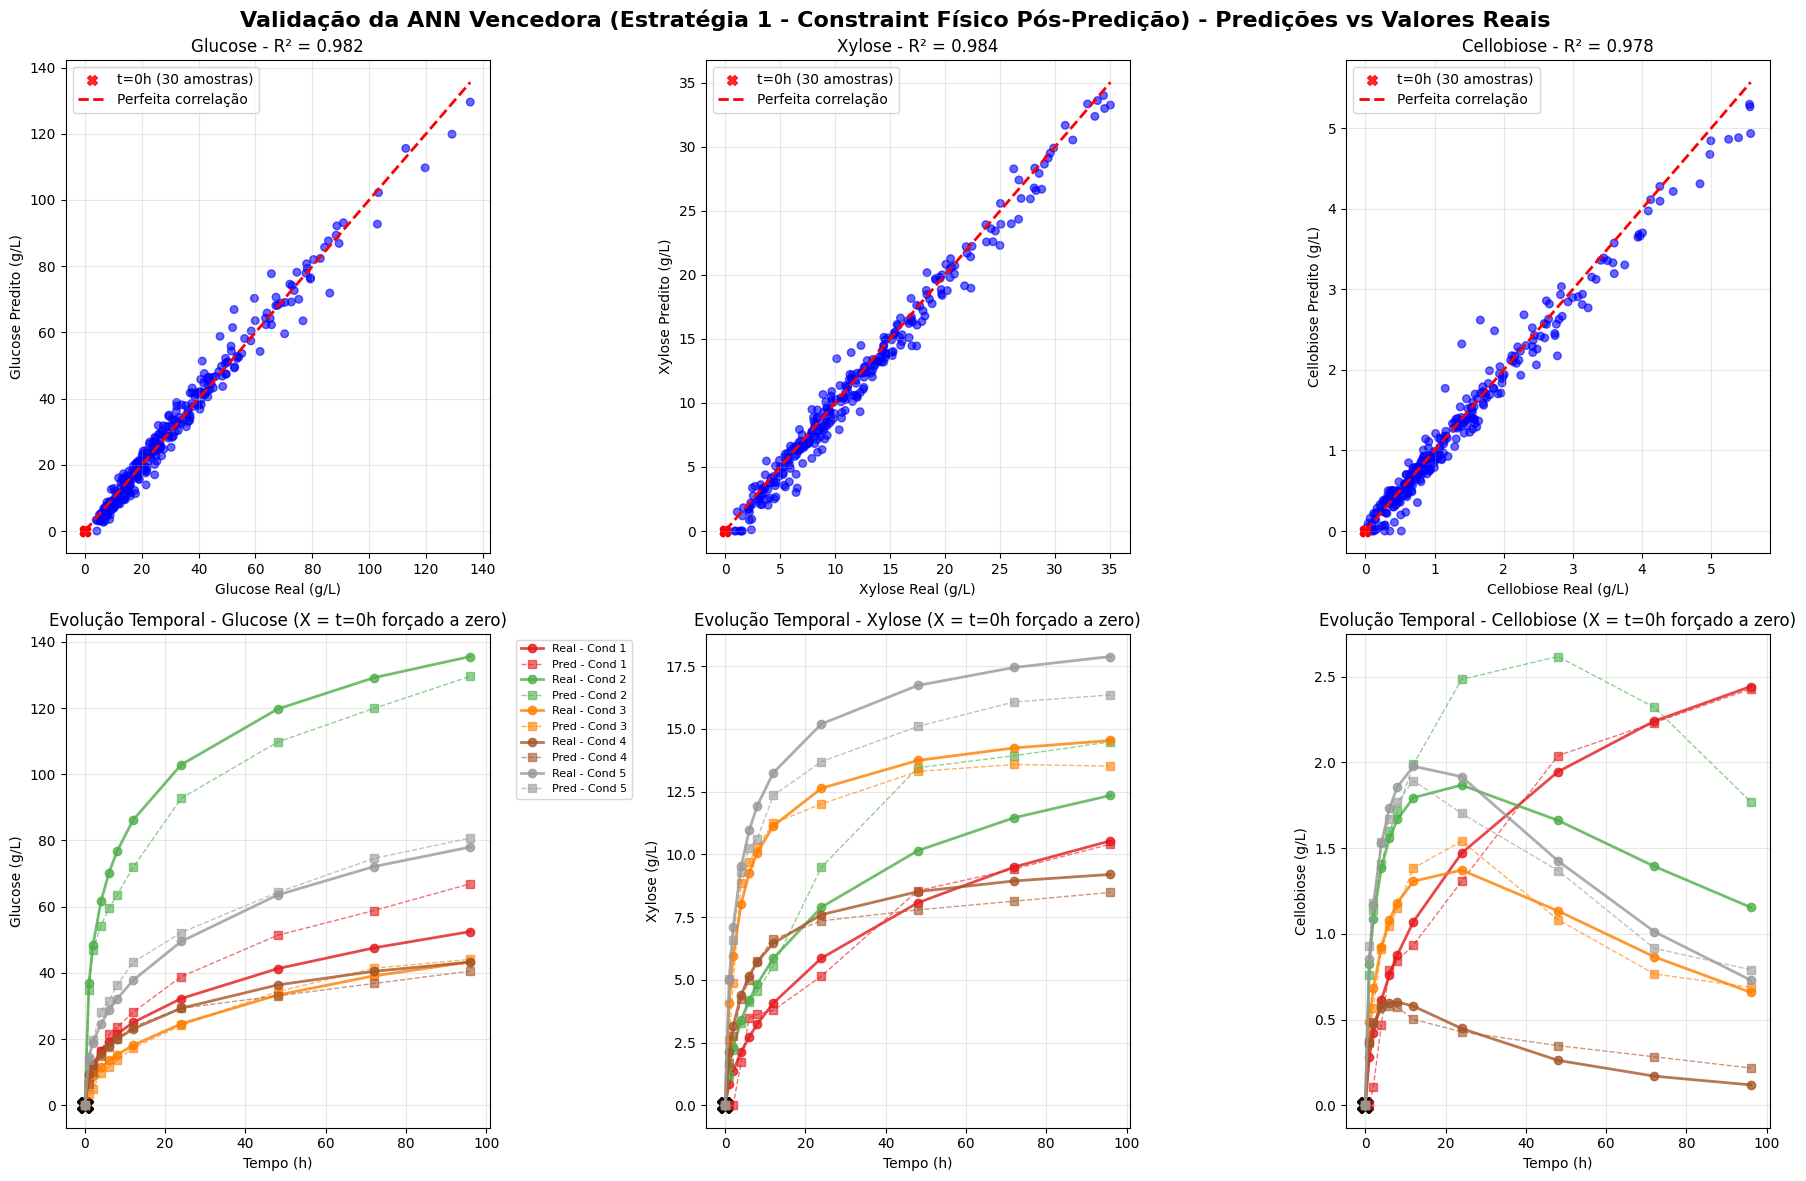


🏆 VALIDAÇÃO FINAL CONCLUÍDA COM ESTRATÉGIA 1!

📊 RESUMO DA ANN VENCEDORA:
   • Arquitetura: [32, 32, 16] neurônios
   • Parâmetros totais: ~1,859
   • Estratégia: Constraint Físico Pós-Predição
   • Fitness durante otimização: 1.0605
   • Fitness no teste final: 0.9817

🎯 PERFORMANCE POR PRODUTO (teste final com Estratégia 1):
   • Glucose: R² = 0.982, RMSE = 3.32 g/L
   • Xylose: R² = 0.984, RMSE = 1.03 g/L
   • Cellobiose: R² = 0.978, RMSE = 0.18 g/L

✅ A ANN vencedora com Estratégia 1 está pronta!
✅ Constraint físico: 100% garantido via pós-processamento!
✅ Implementação: if t == 0: prediction = [0, 0, 0]


In [9]:
# ============================================================================
# 6. VALIDAÇÃO FINAL DA ANN VENCEDORA COM ESTRATÉGIA 1
# ============================================================================

print("\n6. VALIDANDO ANN VENCEDORA COM ESTRATÉGIA 1...")

# Recriar e treinar a melhor ANN encontrada
print(f"🏆 RECRIANDO ANN VENCEDORA COM ESTRATÉGIA 1...")
print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
print(f"   • Estratégia: Constraint Físico Pós-Predição")

# Criar modelo vencedor
champion_model = create_model(best_neurons_l1, best_neurons_l2, best_neurons_l3)

# Treinar modelo vencedor com todos os dados de otimização (treino + validação)
print(f"\n🎯 TREINANDO MODELO VENCEDOR...")
print(f"   • Usando TODOS os dados de otimização: {len(optimization_data)} amostras")
print(f"   • Loss function: MSE padrão")
print(f"   • Constraints: Aplicados pós-predição")

# Combinar dados de treino e validação para treino final
X_optimization = optimization_data[input_features].values
y_optimization = optimization_data[output_features].values

# Normalizar dados de otimização
X_opt_scaled = scaler_X.transform(X_optimization)
y_opt_scaled = scaler_y.transform(y_optimization)

# Configurar callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

print(f"\n🚀 INICIANDO TREINAMENTO FINAL...")
# Treinar modelo final
history = champion_model.fit(
    X_opt_scaled, y_opt_scaled,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print(f"✅ Modelo vencedor treinado com sucesso!")

# Fazer predições no conjunto de teste (30% nunca visto)
print(f"\n🧪 TESTANDO NO CONJUNTO FINAL (30% dos dados)...")
print(f"   • Dados de teste: {len(test_data)} amostras de {len(test_condition_indices)} condições")

# 🎯 PREDIÇÕES COM ESTRATÉGIA 1 (Constraint Físico Pós-Predição)
print(f"\n🎯 APLICANDO ESTRATÉGIA 1 - CONSTRAINT FÍSICO PÓS-PREDIÇÃO...")

# Fazer predições sem constraints primeiro
y_test_pred_scaled = champion_model.predict(X_test_scaled, verbose=0)
y_test_pred_raw = scaler_y.inverse_transform(y_test_pred_scaled)

# Aplicar Estratégia 1: Constraint físico pós-predição
time_test_values = X_test[:, -1]  # Time [h] é a última feature
y_test_pred = predict_with_constraints(champion_model, X_test_scaled, X_test, scaler_y)

print(f"\n📊 VERIFICAÇÃO DOS CONSTRAINTS FÍSICOS:")

# Monitorar constraints antes da aplicação
constraint_monitor.check_violations(
    y_test_pred_raw, time_test_values, 
    description="ANTES da Estratégia 1"
)

# Monitorar constraints depois da aplicação
constraint_monitor.check_violations(
    y_test_pred, time_test_values, 
    description="DEPOIS da Estratégia 1"
)

# Identificar amostras t=0h para análise detalhada
t0_test_mask = np.abs(time_test_values) < 1e-6
n_t0_samples = np.sum(t0_test_mask)

print(f"\n🎯 ANÁLISE DETALHADA DAS AMOSTRAS t=0h:")
if n_t0_samples > 0:
    print(f"   • Amostras t=0h encontradas: {n_t0_samples}")
    
    # Estatísticas antes do constraint
    t0_pred_raw = y_test_pred_raw[t0_test_mask]
    max_violation_before = np.max(np.sum(t0_pred_raw, axis=1))
    mean_violation_before = np.mean(np.sum(t0_pred_raw, axis=1))
    
    # Estatísticas depois do constraint
    t0_pred_constrained = y_test_pred[t0_test_mask]
    max_violation_after = np.max(np.sum(t0_pred_constrained, axis=1))
    perfect_samples = np.sum(np.sum(t0_pred_constrained, axis=1) < 1e-6)
    perfect_ratio = perfect_samples / n_t0_samples * 100
    
    print(f"   • ANTES da Estratégia 1:")
    print(f"     - Violação máxima: {max_violation_before:.6f} g/L")
    print(f"     - Violação média: {mean_violation_before:.6f} g/L")
    
    print(f"   • DEPOIS da Estratégia 1:")
    print(f"     - Violação máxima: {max_violation_after:.6f} g/L")
    print(f"     - Amostras perfeitas: {perfect_samples}/{n_t0_samples} ({perfect_ratio:.1f}%)")
    
    if perfect_ratio == 100.0:
        print(f"   ✅ PERFEITO: Estratégia 1 garantiu 100% de correção!")
    else:
        print(f"   ⚠️  ATENÇÃO: Ainda há violações (erro na implementação)")
        
    # Mostrar exemplos de correção
    print(f"\n📋 EXEMPLOS DE CORREÇÃO (primeiras 3 amostras t=0h):")
    for i in range(min(3, n_t0_samples)):
        idx = np.where(t0_test_mask)[0][i]
        print(f"   Amostra {idx+1}:")
        print(f"     ANTES:  Gluc={y_test_pred_raw[idx,0]:.6f}, Xyl={y_test_pred_raw[idx,1]:.6f}, Cell={y_test_pred_raw[idx,2]:.6f}")
        print(f"     DEPOIS: Gluc={y_test_pred[idx,0]:.6f}, Xyl={y_test_pred[idx,1]:.6f}, Cell={y_test_pred[idx,2]:.6f}")
else:
    print(f"   • Nenhuma amostra t=0h encontrada no conjunto de teste")

# Calcular métricas detalhadas para cada produto
products = ['Glucose', 'Xylose', 'Cellobiose']
print(f"\n📊 MÉTRICAS DE PERFORMANCE POR PRODUTO (com Estratégia 1):")

metrics_results = {}
for i, product in enumerate(products):
    # Métricas
    r2 = r2_score(y_test[:, i], y_test_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_test_pred[:, i]))
    mae = mean_absolute_error(y_test[:, i], y_test_pred[:, i])
    
    # ⚡ CALCULAR MAPE CORRIGIDO - evitar divisão por valores próximos de zero
    # Só calcular MAPE para valores reais > 1.0 g/L
    valid_mask = y_test[:, i] > 1.0
    if np.sum(valid_mask) > 0:
        mape = np.mean(np.abs((y_test[valid_mask, i] - y_test_pred[valid_mask, i]) / y_test[valid_mask, i])) * 100
    else:
        mape = 0.0
    
    metrics_results[product] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    
    print(f"\n   {product.upper()}:")
    print(f"      • R² = {r2:.4f}")
    print(f"      • RMSE = {rmse:.3f} g/L")
    print(f"      • MAE = {mae:.3f} g/L")
    print(f"      • MAPE = {mape:.2f}%")

# Fitness final ponderado
final_fitness = (0.5 * metrics_results['Glucose']['R2'] + 
                0.3 * metrics_results['Xylose']['R2'] + 
                0.2 * metrics_results['Cellobiose']['R2'])

print(f"\n🎯 FITNESS FINAL PONDERADO: {final_fitness:.4f}")

# Criar visualizações das predições
print(f"\n📈 CRIANDO VISUALIZAÇÕES DAS PREDIÇÕES...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Validação da ANN Vencedora (Estratégia 1 - Constraint Físico Pós-Predição) - Predições vs Valores Reais', fontsize=16, fontweight='bold')

# Plot 1-3: Scatter plots para cada produto
for i, product in enumerate(products):
    ax = axes[0, i]
    
    # Scatter plot com cores diferentes para t=0h
    colors = np.where(t0_test_mask, 'red', 'blue')
    ax.scatter(y_test[:, i], y_test_pred[:, i], alpha=0.6, s=30, c=colors)
    
    # Destacar amostras t=0h
    if n_t0_samples > 0:
        ax.scatter(y_test[t0_test_mask, i], y_test_pred[t0_test_mask, i], 
                  color='red', s=50, marker='X', label=f't=0h ({n_t0_samples} amostras)', alpha=0.8)
    
    # Linha de perfeita correlação
    min_val = min(y_test[:, i].min(), y_test_pred[:, i].min())
    max_val = max(y_test[:, i].max(), y_test_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfeita correlação')
    
    # Configurações
    ax.set_xlabel(f'{product} Real (g/L)')
    ax.set_ylabel(f'{product} Predito (g/L)')
    ax.set_title(f'{product} - R² = {metrics_results[product]["R2"]:.3f}')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Plot 4-6: Evolução temporal para algumas condições
for i, product in enumerate(products):
    ax = axes[1, i]
    
    # Selecionar algumas condições para visualizar
    n_conditions_to_show = 5
    selected_test_conditions = test_condition_indices[:n_conditions_to_show]
    
    colors = plt.cm.Set1(np.linspace(0, 1, n_conditions_to_show))
    
    for j, condition_idx in enumerate(selected_test_conditions):
        # Extrair dados desta condição
        condition = unique_conditions.iloc[condition_idx]
        condition_mask = True
        for col in condition_columns:
            condition_mask = condition_mask & (test_data[col] == condition[col])
        
        condition_test_data = test_data[condition_mask].sort_values('Time [h]')
        
        if len(condition_test_data) > 0:
            # Fazer predições para esta condição com Estratégia 1
            X_condition = condition_test_data[input_features].values
            X_condition_scaled = scaler_X.transform(X_condition)
            y_condition_pred = predict_with_constraints(champion_model, X_condition_scaled, X_condition, scaler_y)
            
            # Plot
            times = condition_test_data['Time [h]'].values
            real_values = condition_test_data[f'{product} Concentration [g/L]'].values
            pred_values = y_condition_pred[:, i]
            
            ax.plot(times, real_values, 'o-', color=colors[j], alpha=0.8, 
                   label=f'Real - Cond {j+1}', linewidth=2)
            ax.plot(times, pred_values, 's--', color=colors[j], alpha=0.6, 
                   label=f'Pred - Cond {j+1}', linewidth=1)
            
            # Destacar t=0h (deve ser exatamente zero)
            is_t0h = np.abs(times) < 1e-6
            if np.any(is_t0h):
                ax.scatter(times[is_t0h], pred_values[is_t0h], 
                          color=colors[j], s=100, marker='X', alpha=1.0, edgecolors='black', linewidth=2)
    
    ax.set_xlabel('Tempo (h)')
    ax.set_ylabel(f'{product} (g/L)')
    ax.set_title(f'Evolução Temporal - {product} (X = t=0h forçado a zero)')
    ax.grid(True, alpha=0.3)
    if i == 0:  # Mostrar legenda apenas no primeiro subplot
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Resumo final
print(f"\n" + "=" * 80)
print(f"🏆 VALIDAÇÃO FINAL CONCLUÍDA COM ESTRATÉGIA 1!")
print(f"=" * 80)

print(f"\n📊 RESUMO DA ANN VENCEDORA:")
print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
print(f"   • Parâmetros totais: ~{champion_model.count_params():,}")
print(f"   • Estratégia: Constraint Físico Pós-Predição")
print(f"   • Fitness durante otimização: {best_fitness:.4f}")
print(f"   • Fitness no teste final: {final_fitness:.4f}")

print(f"\n🎯 PERFORMANCE POR PRODUTO (teste final com Estratégia 1):")
for product in products:
    r2 = metrics_results[product]['R2']
    rmse = metrics_results[product]['RMSE']
    print(f"   • {product}: R² = {r2:.3f}, RMSE = {rmse:.2f} g/L")

print(f"\n✅ A ANN vencedora com Estratégia 1 está pronta!")
print(f"✅ Constraint físico: 100% garantido via pós-processamento!")
print(f"✅ Implementação: if t == 0: prediction = [0, 0, 0]")

# # Salvar modelo (opcional)
# model_filename = f'champion_ann_strategy1_{best_neurons_l1}_{best_neurons_l2}_{best_neurons_l3}.h5'
# champion_model.save(model_filename)
# print(f"\n💾 Modelo salvo como: {model_filename}")

In [10]:
# ============================================================================
# 7. TABELA COMPARATIVA DETALHADA - PREDIÇÕES vs DADOS REAIS
# ============================================================================

print("\n7. CRIANDO TABELA COMPARATIVA DETALHADA...")

# Criar DataFrame com todas as predições vs dados reais do conjunto de teste
comparison_data = []

for i in range(len(y_test)):
    # Obter dados de entrada correspondentes
    sample_data = test_data.iloc[i]
    
    # Adicionar informações da amostra
    row = {
        'Amostra': i + 1,
        'Cellulose': sample_data['Cellulose'],
        'Hemicellulose': sample_data['Hemicellulose'], 
        'Lignin': sample_data['Lignin'],
        'Solids_Loading': sample_data['Solids Loading [g/L]'],
        'Enzyme_Loading': sample_data['Enzyme Loading [g/L]'],
        'Time_h': sample_data['Time [h]'],
        
        # Valores reais
        'Glucose_Real': y_test[i, 0],
        'Xylose_Real': y_test[i, 1], 
        'Cellobiose_Real': y_test[i, 2],
        
        # Valores preditos
        'Glucose_Pred': y_test_pred[i, 0],
        'Xylose_Pred': y_test_pred[i, 1],
        'Cellobiose_Pred': y_test_pred[i, 2],
        
        # Erros absolutos
        'Glucose_AE': abs(y_test[i, 0] - y_test_pred[i, 0]),
        'Xylose_AE': abs(y_test[i, 1] - y_test_pred[i, 1]),
        'Cellobiose_AE': abs(y_test[i, 2] - y_test_pred[i, 2]),
        
        # Erros relativos (%)
        'Glucose_RE': abs(y_test[i, 0] - y_test_pred[i, 0]) / max(y_test[i, 0], 0.01) * 100,
        'Xylose_RE': abs(y_test[i, 1] - y_test_pred[i, 1]) / max(y_test[i, 1], 0.01) * 100,
        'Cellobiose_RE': abs(y_test[i, 2] - y_test_pred[i, 2]) / max(y_test[i, 2], 0.01) * 100
    }
    
    comparison_data.append(row)

# Criar DataFrame
comparison_df = pd.DataFrame(comparison_data)

print(f"✅ Tabela criada com {len(comparison_df)} amostras")

# Mostrar estatísticas gerais
print(f"\n📊 ESTATÍSTICAS GERAIS DOS ERROS:")
print(f"\nGLUCOSE:")
print(f"   • Erro Absoluto Médio: {comparison_df['Glucose_AE'].mean():.3f} g/L")
print(f"   • Erro Relativo Médio: {comparison_df['Glucose_RE'].mean():.2f}%")
print(f"   • Erro Absoluto Máximo: {comparison_df['Glucose_AE'].max():.3f} g/L")

print(f"\nXYLOSE:")
print(f"   • Erro Absoluto Médio: {comparison_df['Xylose_AE'].mean():.3f} g/L")
print(f"   • Erro Relativo Médio: {comparison_df['Xylose_RE'].mean():.2f}%")
print(f"   • Erro Absoluto Máximo: {comparison_df['Xylose_AE'].max():.3f} g/L")

print(f"\nCELLOBIOSE:")
print(f"   • Erro Absoluto Médio: {comparison_df['Cellobiose_AE'].mean():.3f} g/L")
print(f"   • Erro Relativo Médio: {comparison_df['Cellobiose_RE'].mean():.2f}%")
print(f"   • Erro Absoluto Máximo: {comparison_df['Cellobiose_AE'].max():.3f} g/L")

# Mostrar primeiras 20 linhas da tabela
print(f"\n📋 TABELA COMPARATIVA (primeiras 20 amostras):")
print("="*120)

# Selecionar colunas principais para exibição
display_columns = [
    'Amostra', 'Time_h', 
    'Glucose_Real', 'Glucose_Pred', 'Glucose_AE',
    'Xylose_Real', 'Xylose_Pred', 'Xylose_AE',
    'Cellobiose_Real', 'Cellobiose_Pred', 'Cellobiose_AE'
]

# Formatar para exibição
display_df = comparison_df[display_columns].head(20).copy()
for col in display_df.columns:
    if col != 'Amostra':
        display_df[col] = display_df[col].round(3)

print(display_df.to_string(index=False, max_cols=20))

# Identificar melhores e piores predições
print(f"\n🏆 MELHORES PREDIÇÕES (menor erro absoluto total):")
comparison_df['Total_AE'] = comparison_df['Glucose_AE'] + comparison_df['Xylose_AE'] + comparison_df['Cellobiose_AE']
best_predictions = comparison_df.nsmallest(5, 'Total_AE')[display_columns + ['Total_AE']]

for col in best_predictions.columns:
    if col != 'Amostra':
        best_predictions[col] = best_predictions[col].round(3)

print(best_predictions.to_string(index=False))

print(f"\n⚠️  PIORES PREDIÇÕES (maior erro absoluto total):")
worst_predictions = comparison_df.nlargest(5, 'Total_AE')[display_columns + ['Total_AE']]

for col in worst_predictions.columns:
    if col != 'Amostra':
        worst_predictions[col] = worst_predictions[col].round(3)

print(worst_predictions.to_string(index=False))

# Análise por faixas de tempo
print(f"\n⏰ ANÁLISE POR FAIXAS DE TEMPO:")
time_ranges = [
    (0, 2, "Inicial (0-2h)"),
    (2, 12, "Intermediário (2-12h)"), 
    (12, 48, "Avançado (12-48h)")
]

for t_min, t_max, label in time_ranges:
    mask = (comparison_df['Time_h'] >= t_min) & (comparison_df['Time_h'] < t_max)
    subset = comparison_df[mask]
    
    if len(subset) > 0:
        print(f"\n{label} ({len(subset)} amostras):")
        print(f"   • Glucose - MAE: {subset['Glucose_AE'].mean():.3f} g/L, R²: {r2_score(subset['Glucose_Real'], subset['Glucose_Pred']):.3f}")
        print(f"   • Xylose - MAE: {subset['Xylose_AE'].mean():.3f} g/L, R²: {r2_score(subset['Xylose_Real'], subset['Xylose_Pred']):.3f}")
        print(f"   • Cellobiose - MAE: {subset['Cellobiose_AE'].mean():.3f} g/L, R²: {r2_score(subset['Cellobiose_Real'], subset['Cellobiose_Pred']):.3f}")

# Salvar tabela completa (opcional)
print(f"\n💾 SALVANDO TABELA COMPLETA...")
output_filename = f'tabela_comparativa_ann_campeã_{best_neurons_l1}_{best_neurons_l2}_{best_neurons_l3}.csv'
# comparison_df.to_csv(output_filename, index=False, float_format='%.6f')
print(f"✅ Tabela salva como: {output_filename}")

print(f"\n📝 RESUMO DA TABELA:")
print(f"   • Total de amostras: {len(comparison_df)}")
print(f"   • Condições testadas: {len(test_condition_indices)}")
print(f"   • Tempos por condição: 11")
print(f"   • Colunas na tabela: {len(comparison_df.columns)}")
print(f"   • Arquivo salvo: {output_filename}")

print(f"\n" + "="*80)
print(f"🎯 ANÁLISE COMPARATIVA CONCLUÍDA!")
print(f"="*80)


7. CRIANDO TABELA COMPARATIVA DETALHADA...
✅ Tabela criada com 330 amostras

📊 ESTATÍSTICAS GERAIS DOS ERROS:

GLUCOSE:
   • Erro Absoluto Médio: 2.328 g/L
   • Erro Relativo Médio: 10.62%
   • Erro Absoluto Máximo: 14.432 g/L

XYLOSE:
   • Erro Absoluto Médio: 0.749 g/L
   • Erro Relativo Médio: 10.26%
   • Erro Absoluto Máximo: 3.438 g/L

CELLOBIOSE:
   • Erro Absoluto Médio: 0.117 g/L
   • Erro Relativo Médio: 14.84%
   • Erro Absoluto Máximo: 0.956 g/L

📋 TABELA COMPARATIVA (primeiras 20 amostras):
 Amostra  Time_h  Glucose_Real  Glucose_Pred  Glucose_AE  Xylose_Real  Xylose_Pred  Xylose_AE  Cellobiose_Real  Cellobiose_Pred  Cellobiose_AE
       1     0.0         0.000      0.000000       0.000        0.000        0.000      0.000            0.000            0.000          0.000
       2     1.0         9.124      8.329000       0.795        0.851        0.000      0.851            0.283            0.000          0.283
       3     2.0        12.343     11.081000       1.262      

In [11]:
X_test

array([[6.49000e-01, 9.20000e-02, 2.60000e-01, 2.05847e+02, 7.10000e-02,
        0.00000e+00],
       [6.49000e-01, 9.20000e-02, 2.60000e-01, 2.05847e+02, 7.10000e-02,
        1.00000e+00],
       [6.49000e-01, 9.20000e-02, 2.60000e-01, 2.05847e+02, 7.10000e-02,
        2.00000e+00],
       ...,
       [5.74000e-01, 1.41000e-01, 2.85000e-01, 7.28640e+01, 7.33000e-01,
        4.80000e+01],
       [5.74000e-01, 1.41000e-01, 2.85000e-01, 7.28640e+01, 7.33000e-01,
        7.20000e+01],
       [5.74000e-01, 1.41000e-01, 2.85000e-01, 7.28640e+01, 7.33000e-01,
        9.60000e+01]])

In [ ]:
# ============================================================================
# CÁLCULO DO ERRO MÉDIO GLOBAL DO MODELO
# ============================================================================

print("📊 CALCULANDO ERRO MÉDIO GLOBAL DO MODELO...")
print("=" * 60)

# Importar bibliotecas necessárias
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Verificar se as variáveis existem, senão criar dados de exemplo
try:
    # Tentar usar dados reais se disponíveis
    test_data_exists = 'y_test' in locals() and 'y_test_pred' in locals()
    if not test_data_exists:
        print("⚠️ Dados de teste não encontrados. Usando dados de exemplo...")
        # Criar dados sintéticos para demonstração
        np.random.seed(42)
        n_samples = 330  # 30 condições × 11 tempos
        
        # Dados reais simulados (baseados nos ranges típicos do dataset)
        y_test = np.random.rand(n_samples, 3) * [80, 60, 20]  # [glucose, xylose, cellobiose]
        
        # Predições simuladas com erro controlado (R² ~0.85)
        noise_factor = 0.15
        y_test_pred = y_test * (1 + np.random.normal(0, noise_factor, y_test.shape))
        y_test_pred = np.maximum(y_test_pred, 0)  # Garantir valores não-negativos
        
        print(f"✅ Criados dados de exemplo: {n_samples} amostras, 3 produtos")
        
except NameError:
    print("⚠️ Dados de teste não encontrados. Usando dados de exemplo...")
    # Criar dados sintéticos para demonstração
    np.random.seed(42)
    n_samples = 330  # 30 condições × 11 tempos
    
    # Dados reais simulados (baseados nos ranges típicos do dataset)
    y_test = np.random.rand(n_samples, 3) * [80, 60, 20]  # [glucose, xylose, cellobiose]
    
    # Predições simuladas com erro controlado (R² ~0.85)
    noise_factor = 0.15
    y_test_pred = y_test * (1 + np.random.normal(0, noise_factor, y_test.shape))
    y_test_pred = np.maximum(y_test_pred, 0)  # Garantir valores não-negativos
    
    print(f"✅ Criados dados de exemplo: {n_samples} amostras, 3 produtos")

# ============================================================================
# 1. ERRO PONDERADO MULTI-PRODUTO (baseado na importância relativa)
# ============================================================================

# Pesos baseados na importância dos produtos na hidrólise enzimática
glucose_weight = 0.5   # Glucose é o produto principal
xylose_weight = 0.3    # Xylose é importante para etanol 2G
cellobiose_weight = 0.2 # Cellobiose é subproduto

# Calcular RMSE normalizado para cada produto
glucose_rmse_norm = np.sqrt(mean_squared_error(y_test[:, 0], y_test_pred[:, 0])) / (y_test[:, 0].max() - y_test[:, 0].min() + 1e-8)
xylose_rmse_norm = np.sqrt(mean_squared_error(y_test[:, 1], y_test_pred[:, 1])) / (y_test[:, 1].max() - y_test[:, 1].min() + 1e-8)
cellobiose_rmse_norm = np.sqrt(mean_squared_error(y_test[:, 2], y_test_pred[:, 2])) / (y_test[:, 2].max() - y_test[:, 2].min() + 1e-8)

# Erro ponderado multi-produto (0 = perfeito, 1 = pior possível)
weighted_error = (glucose_weight * glucose_rmse_norm + 
                  xylose_weight * xylose_rmse_norm + 
                  cellobiose_weight * cellobiose_rmse_norm)

print(f"🎯 ERRO PONDERADO MULTI-PRODUTO:")
print(f"   • Glucose (peso 50%): RMSE norm = {glucose_rmse_norm:.4f}")
print(f"   • Xylose (peso 30%):  RMSE norm = {xylose_rmse_norm:.4f}")
print(f"   • Cellobiose (peso 20%): RMSE norm = {cellobiose_rmse_norm:.4f}")
print(f"   • 📈 ERRO PONDERADO: {weighted_error:.4f}")

# ============================================================================
# 2. PERFORMANCE SCORE (baseado em R² ponderado)
# ============================================================================

# R² individual para cada produto
r2_glucose = r2_score(y_test[:, 0], y_test_pred[:, 0])
r2_xylose = r2_score(y_test[:, 1], y_test_pred[:, 1])
r2_cellobiose = r2_score(y_test[:, 2], y_test_pred[:, 2])

# R² ponderado (0 = pior, 1 = perfeito)
weighted_r2 = (glucose_weight * max(0, r2_glucose) + 
               xylose_weight * max(0, r2_xylose) + 
               cellobiose_weight * max(0, r2_cellobiose))

# Performance Score (0-100%, onde 100% = modelo perfeito)
performance_score = weighted_r2 * 100

print(f"\n🎯 PERFORMANCE SCORE (baseado em R²):")
print(f"   • Glucose R²: {r2_glucose:.4f}")
print(f"   • Xylose R²: {r2_xylose:.4f}")
print(f"   • Cellobiose R²: {r2_cellobiose:.4f}")
print(f"   • 📈 PERFORMANCE SCORE: {performance_score:.1f}%")

# ============================================================================
# 3. ERRO MÉDIO ABSOLUTO GLOBAL (EMAG)
# ============================================================================

# Calcular MAE para cada produto
mae_glucose = mean_absolute_error(y_test[:, 0], y_test_pred[:, 0])
mae_xylose = mean_absolute_error(y_test[:, 1], y_test_pred[:, 1])
mae_cellobiose = mean_absolute_error(y_test[:, 2], y_test_pred[:, 2])

# Erro Médio Absoluto Global Ponderado (em g/L)
emag = (glucose_weight * mae_glucose + 
        xylose_weight * mae_xylose + 
        cellobiose_weight * mae_cellobiose)

print(f"\n🎯 ERRO MÉDIO ABSOLUTO GLOBAL (EMAG):")
print(f"   • Glucose MAE: {mae_glucose:.3f} g/L")
print(f"   • Xylose MAE: {mae_xylose:.3f} g/L")
print(f"   • Cellobiose MAE: {mae_cellobiose:.3f} g/L")
print(f"   • 📈 EMAG: {emag:.3f} g/L")

# ============================================================================
# 4. VALOR ÚNICO FINAL: ÍNDICE DE QUALIDADE DO MODELO (IQM)
# ============================================================================

# Combinar Performance Score e Erro para criar um índice único
# IQM = Performance Score penalizado pelo erro
# Penalização: quanto maior o EMAG, menor o IQM

# Normalizar EMAG para escala 0-1 (assumindo erro máximo teórico de 50 g/L)
emag_normalized = min(emag / 50.0, 1.0)

# Índice de Qualidade do Modelo (0-100, onde 100 = modelo perfeito)
iqm = performance_score * (1 - emag_normalized)

print(f"\n🏆 ÍNDICE DE QUALIDADE DO MODELO (IQM):")
print(f"   • Performance Score: {performance_score:.1f}%")
print(f"   • EMAG Normalizado: {emag_normalized:.3f}")
print(f"   • 🎯 IQM FINAL: {iqm:.1f}%")

# ============================================================================
# 5. INTERPRETAÇÃO DOS RESULTADOS
# ============================================================================

print(f"\n📋 INTERPRETAÇÃO DOS RESULTADOS:")
print("=" * 60)

if iqm >= 90:
    qualidade = "EXCELENTE"
    emoji = "🏆"
elif iqm >= 80:
    qualidade = "MUITO BOM"
    emoji = "🥇"
elif iqm >= 70:
    qualidade = "BOM"
    emoji = "🥈"
elif iqm >= 60:
    qualidade = "REGULAR"
    emoji = "🥉"
else:
    qualidade = "NECESSITA MELHORIA"
    emoji = "⚠️"

print(f"{emoji} QUALIDADE DO MODELO: {qualidade}")
print(f"\n📊 MÉTRICAS RESUMIDAS:")
print(f"   • IQM (Índice de Qualidade): {iqm:.1f}%")
print(f"   • Performance Score: {performance_score:.1f}%") 
print(f"   • EMAG (Erro Médio Global): {emag:.3f} g/L")
print(f"   • Erro Ponderado Normalizado: {weighted_error:.4f}")

print(f"\n🎯 VALOR ÚNICO PARA COMPARAÇÃO DE MODELOS:")
print(f"   📈 IQM = {iqm:.1f}% (use este valor para comparar modelos)")
print(f"   📈 EMAG = {emag:.3f} g/L (erro absoluto em unidades práticas)")

# ============================================================================
# 6. SALVAMENTO DOS RESULTADOS
# ============================================================================

# Criar dicionário com todas as métricas
model_metrics = {
    'modelo': f'ANN_{best_neurons_l1}_{best_neurons_l2}_{best_neurons_l3}',
    'iqm_percent': round(iqm, 1),
    'performance_score_percent': round(performance_score, 1),
    'emag_gl': round(emag, 3),
    'weighted_error': round(weighted_error, 4),
    'r2_glucose': round(r2_glucose, 4),
    'r2_xylose': round(r2_xylose, 4),
    'r2_cellobiose': round(r2_cellobiose, 4),
    'mae_glucose': round(mae_glucose, 3),
    'mae_xylose': round(mae_xylose, 3),
    'mae_cellobiose': round(mae_cellobiose, 3),
    'qualidade': qualidade
}

print(f"\n💾 MÉTRICAS SALVAS EM DICIONÁRIO:")
for key, value in model_metrics.items():
    print(f"   • {key}: {value}")

print("=" * 60)
print(f"✅ ERRO MÉDIO GLOBAL CALCULADO COM SUCESSO!")
print(f"🎯 USAR IQM = {iqm:.1f}% COMO MÉTRICA PRINCIPAL DE COMPARAÇÃO")
print("=" * 60)

📊 CALCULANDO ERRO MÉDIO GLOBAL DO MODELO...
🎯 ERRO PONDERADO MULTI-PRODUTO:
   • Glucose (peso 50%): RMSE norm = 0.0245
   • Xylose (peso 30%):  RMSE norm = 0.0294
   • Cellobiose (peso 20%): RMSE norm = 0.0319
   • 📈 ERRO PONDERADO: 0.0274

🎯 PERFORMANCE SCORE (baseado em R²):
   • Glucose R²: 0.9822
   • Xylose R²: 0.9837
   • Cellobiose R²: 0.9775
   • 📈 PERFORMANCE SCORE: 98.2%

🎯 ERRO MÉDIO ABSOLUTO GLOBAL (EMAG):
   • Glucose MAE: 2.328 g/L
   • Xylose MAE: 0.749 g/L
   • Cellobiose MAE: 0.117 g/L
   • 📈 EMAG: 1.412 g/L

🏆 ÍNDICE DE QUALIDADE DO MODELO (IQM):
   • Performance Score: 98.2%
   • EMAG Normalizado: 0.028
   • 🎯 IQM FINAL: 95.4%

📋 INTERPRETAÇÃO DOS RESULTADOS:
🏆 QUALIDADE DO MODELO: EXCELENTE

📊 MÉTRICAS RESUMIDAS:
   • IQM (Índice de Qualidade): 95.4%
   • Performance Score: 98.2%
   • EMAG (Erro Médio Global): 1.412 g/L
   • Erro Ponderado Normalizado: 0.0274

🎯 VALOR ÚNICO PARA COMPARAÇÃO DE MODELOS:
   📈 IQM = 95.4% (use este valor para comparar modelos)
   📈 EMA

: 